# 🛒 E-Commerce Customer Behavior Analysis
## CRISP-DM Methodology
---
### Step 1: Business Understanding

**CRISP-DM (Cross-Industry Standard Process for Data Mining)** is a widely used methodology for data mining and analytics projects. It consists of 6 phases:

| Phase | Description |
|-------|-------------|
| 1. Business Understanding | Understand the business objectives and requirements |
| 2. Data Understanding | Explore and familiarize with the data |
| 3. Data Preparation | Clean, transform, and prepare data for modeling |
| 4. Modeling | Apply analytical/ML models |
| 5. Evaluation | Assess model results against business objectives |
| 6. Deployment | Deploy findings and insights |

---
**In this notebook, we focus on Phase 1: Business Understanding** — defining the business context, objectives, and success criteria, along with an initial look at the raw data.

---
## 1.1 Import Required Libraries

In [1]:
# ============================
# Importing Libraries
# ============================

import pandas as pd               # Data manipulation and analysis
import numpy as np                 # Numerical computing
import matplotlib.pyplot as plt    # Data visualization
import seaborn as sns              # Statistical data visualization
import warnings

# Configuration
warnings.filterwarnings('ignore')                     # Suppress warnings for cleaner output
pd.set_option('display.max_columns', None)            # Show all columns
pd.set_option('display.max_rows', None)               # Show all rows
pd.set_option('display.width', None)                  # Auto-detect display width
pd.set_option('display.float_format', '{:.2f}'.format) # Format floats to 2 decimal places

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

print('✅ All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

✅ All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3


---
## 1.2 Load the Dataset

In [2]:
# ============================
# Loading the Dataset
# ============================

df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

print('✅ Dataset loaded successfully!')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded successfully!
Dataset Shape: 350 rows × 11 columns


---
## 1.3 Initial Data Inspection (Basic Commands)

Before diving into business understanding, let's take a quick look at the raw data to understand what we're working with.

### 1.3.1 `head()` — View First Few Rows

In [3]:
# View the first 5 rows (default)
print('='*80)
print('FIRST 5 ROWS OF THE DATASET')
print('='*80)
df.head()

FIRST 5 ROWS OF THE DATASET


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.60,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.10,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.40,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.70,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.00,True,55,Unsatisfied


In [4]:
# View the first 10 rows
print('='*80)
print('FIRST 10 ROWS OF THE DATASET')
print('='*80)
df.head(10)

FIRST 10 ROWS OF THE DATASET


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.60,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.10,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.40,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.70,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.00,True,55,Unsatisfied
5,106,Female,37,Houston,Bronze,440.80,8,3.10,False,22,Neutral
6,107,Female,31,New York,Gold,1150.60,15,4.50,True,28,Satisfied
7,108,Male,35,Los Angeles,Silver,800.90,12,4.20,False,14,Neutral
8,109,Female,41,Chicago,Bronze,495.25,10,3.60,True,40,Unsatisfied
9,110,Male,28,San Francisco,Gold,1520.10,21,4.80,False,9,Satisfied


### 1.3.2 `tail()` — View Last Few Rows

In [5]:
# View the last 5 rows (default)
print('='*80)
print('LAST 5 ROWS OF THE DATASET')
print('='*80)
df.tail()

LAST 5 ROWS OF THE DATASET


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
345,446,Male,32,Miami,Silver,660.30,10,3.80,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.00,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.50,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.20,False,21,Neutral
349,450,Female,43,Chicago,Bronze,515.75,10,3.30,True,49,Unsatisfied


In [6]:
# View the last 10 rows
print('='*80)
print('LAST 10 ROWS OF THE DATASET')
print('='*80)
df.tail(10)

LAST 10 ROWS OF THE DATASET


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
340,441,Female,37,Houston,Bronze,450.80,7,3.40,False,32,Neutral
341,442,Female,31,New York,Gold,1140.60,15,4.50,True,36,Satisfied
342,443,Male,35,Los Angeles,Silver,800.90,12,4.10,False,20,Neutral
343,444,Female,41,Chicago,Bronze,475.25,9,3.60,True,48,Unsatisfied
344,445,Male,28,San Francisco,Gold,1480.10,21,4.90,False,13,Satisfied
345,446,Male,32,Miami,Silver,660.30,10,3.80,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.00,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.50,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.20,False,21,Neutral
349,450,Female,43,Chicago,Bronze,515.75,10,3.30,True,49,Unsatisfied


### 1.3.3 `shape` — Dataset Dimensions

In [7]:
# Get the shape of the dataset
print('='*80)
print('DATASET DIMENSIONS')
print('='*80)
print(f'Number of Rows    : {df.shape[0]}')
print(f'Number of Columns : {df.shape[1]}')
print(f'Total Data Points : {df.shape[0] * df.shape[1]}')

DATASET DIMENSIONS
Number of Rows    : 350
Number of Columns : 11
Total Data Points : 3850


### 1.3.4 `columns` — Column Names

In [8]:
# List all column names
print('='*80)
print('COLUMN NAMES')
print('='*80)
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')
print(f'\nTotal Columns: {len(df.columns)}')

COLUMN NAMES
   1. Customer ID
   2. Gender
   3. Age
   4. City
   5. Membership Type
   6. Total Spend
   7. Items Purchased
   8. Average Rating
   9. Discount Applied
  10. Days Since Last Purchase
  11. Satisfaction Level

Total Columns: 11


### 1.3.5 `dtypes` — Data Types of Each Column

In [9]:
# Check data types of each column
print('='*80)
print('DATA TYPES')
print('='*80)
print(df.dtypes)
print('\n--- Summary ---')
print(df.dtypes.value_counts())

DATA TYPES
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level           object
dtype: object

--- Summary ---
int64      4
object     4
float64    2
bool       1
Name: count, dtype: int64


### 1.3.6 `info()` — Comprehensive Dataset Information

In [10]:
# Get detailed information about the dataset
print('='*80)
print('DATASET INFO')
print('='*80)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


### 1.3.7 `describe()` — Statistical Summary

In [11]:
# Descriptive statistics for NUMERICAL columns
print('='*80)
print('DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS')
print('='*80)
df.describe()

DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS


,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.00,350.00,350.00,350.00,350.00,350.00
mean,275.50,33.60,845.38,12.60,4.02,26.59
std,101.18,4.87,362.06,4.16,0.58,13.44
min,101.00,26.00,410.80,7.00,3.00,9.00
25%,188.25,30.00,502.00,9.00,3.50,15.00
50%,275.50,32.50,775.20,12.00,4.10,23.00
75%,362.75,37.00,1160.60,15.00,4.50,38.00
max,450.00,43.00,1520.10,21.00,4.90,63.00


In [12]:
# Descriptive statistics for CATEGORICAL columns
print('='*80)
print('DESCRIPTIVE STATISTICS — CATEGORICAL COLUMNS')
print('='*80)
df.describe(include='object')

DESCRIPTIVE STATISTICS — CATEGORICAL COLUMNS


,Gender,City,Membership Type,Satisfaction Level
count,350,350,350,348
unique,2,6,3,3
top,Female,New York,Gold,Satisfied
freq,175,59,117,125


In [13]:
# Descriptive statistics for ALL columns
print('='*80)
print('DESCRIPTIVE STATISTICS — ALL COLUMNS')
print('='*80)
df.describe(include='all')

DESCRIPTIVE STATISTICS — ALL COLUMNS


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,350.00,350,350.00,350,350,350.00,350.00,350.00,350,350.00,348
unique,NaN,2,NaN,6,3,NaN,NaN,NaN,2,NaN,3
top,NaN,Female,NaN,New York,Gold,NaN,NaN,NaN,True,NaN,Satisfied
freq,NaN,175,NaN,59,117,NaN,NaN,NaN,175,NaN,125
mean,275.50,NaN,33.60,NaN,NaN,845.38,12.60,4.02,NaN,26.59,NaN
std,101.18,NaN,4.87,NaN,NaN,362.06,4.16,0.58,NaN,13.44,NaN
min,101.00,NaN,26.00,NaN,NaN,410.80,7.00,3.00,NaN,9.00,NaN
25%,188.25,NaN,30.00,NaN,NaN,502.00,9.00,3.50,NaN,15.00,NaN
50%,275.50,NaN,32.50,NaN,NaN,775.20,12.00,4.10,NaN,23.00,NaN
75%,362.75,NaN,37.00,NaN,NaN,1160.60,15.00,4.50,NaN,38.00,NaN


### 1.3.8 `sample()` — View Random Rows

In [14]:
# View 5 random rows from the dataset
print('='*80)
print('5 RANDOM ROWS FROM THE DATASET')
print('='*80)
df.sample(5, random_state=42)

5 RANDOM ROWS FROM THE DATASET


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
157,258,Male,35,Los Angeles,Silver,810.90,12,4.30,False,13,Neutral
341,442,Female,31,New York,Gold,1140.60,15,4.50,True,36,Satisfied
315,416,Male,27,Miami,Silver,710.40,13,4.10,True,61,Unsatisfied
234,335,Male,33,Los Angeles,Silver,830.75,13,4.20,False,14,Satisfied
155,256,Female,37,Houston,Bronze,430.80,7,3.40,False,23,Neutral


### 1.3.9 `nunique()` — Count Unique Values

In [15]:
# Count unique values in each column
print('='*80)
print('UNIQUE VALUES PER COLUMN')
print('='*80)
for col in df.columns:
    print(f'  {col:<30} → {df[col].nunique():>4} unique values')
print(f'\nTotal unique Customer IDs: {df["Customer ID"].nunique()}')

UNIQUE VALUES PER COLUMN
  Customer ID                    →  350 unique values
  Gender                         →    2 unique values
  Age                            →   16 unique values
  City                           →    6 unique values
  Membership Type                →    3 unique values
  Total Spend                    →   76 unique values
  Items Purchased                →   15 unique values
  Average Rating                 →   20 unique values
  Discount Applied               →    2 unique values
  Days Since Last Purchase       →   54 unique values
  Satisfaction Level             →    3 unique values

Total unique Customer IDs: 350


### 1.3.10 `value_counts()` — Frequency Counts for Categorical Columns

In [16]:
# Value counts for each categorical column
categorical_cols = ['Gender', 'City', 'Membership Type', 'Discount Applied', 'Satisfaction Level']

for col in categorical_cols:
    print('='*60)
    print(f'VALUE COUNTS — {col.upper()}')
    print('='*60)
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)})
    print(summary)
    print()

VALUE COUNTS — GENDER
        Count  Percentage (%)
Gender                       
Female    175           50.00
Male      175           50.00

VALUE COUNTS — CITY
               Count  Percentage (%)
City                                
New York          59           16.86
Los Angeles       59           16.86
Chicago           58           16.57
San Francisco     58           16.57
Miami             58           16.57
Houston           58           16.57

VALUE COUNTS — MEMBERSHIP TYPE
                 Count  Percentage (%)
Membership Type                       
Gold               117           33.43
Silver             117           33.43
Bronze             116           33.14

VALUE COUNTS — DISCOUNT APPLIED
                  Count  Percentage (%)
Discount Applied                       
True                175           50.00
False               175           50.00

VALUE COUNTS — SATISFACTION LEVEL
                    Count  Percentage (%)
Satisfaction Level                       
Sa

### 1.3.11 `isnull()` / `isna()` — Missing Values Check

In [17]:
# Check for missing values
print('='*80)
print('MISSING VALUES ANALYSIS')
print('='*80)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values.round(2)
})

print(missing_df.to_string(index=False))
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')
print(f'Total Data Points   : {df.shape[0] * df.shape[1]}')
print(f'Overall Missing %   : {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.4f}%')

MISSING VALUES ANALYSIS
                  Column  Missing Count  Missing %
             Customer ID              0       0.00
                  Gender              0       0.00
                     Age              0       0.00
                    City              0       0.00
         Membership Type              0       0.00
             Total Spend              0       0.00
         Items Purchased              0       0.00
          Average Rating              0       0.00
        Discount Applied              0       0.00
Days Since Last Purchase              0       0.00
      Satisfaction Level              2       0.57

Total Missing Values: 2
Total Data Points   : 3850
Overall Missing %   : 0.0519%


In [18]:
# Identify the exact rows with missing values
print('='*80)
print('ROWS WITH MISSING VALUES')
print('='*80)

rows_with_missing = df[df.isnull().any(axis=1)]
if len(rows_with_missing) > 0:
    print(f'Found {len(rows_with_missing)} row(s) with missing values:\n')
    print(rows_with_missing)
else:
    print('No missing values found in the dataset!')

ROWS WITH MISSING VALUES
Found 2 row(s) with missing values:

     Customer ID  Gender  Age     City Membership Type  Total Spend  \
71           172  Female   37  Houston          Bronze       420.80   
143          244  Female   37  Houston          Bronze       430.80   

     Items Purchased  Average Rating  Discount Applied  \
71                 7            3.10             False   
143                7            3.40             False   

     Days Since Last Purchase Satisfaction Level  
71                         21                NaN  
143                        23                NaN  


### 1.3.12 `duplicated()` — Duplicate Rows Check

In [19]:
# Check for duplicate rows
print('='*80)
print('DUPLICATE ROWS ANALYSIS')
print('='*80)

total_duplicates = df.duplicated().sum()
print(f'Total Duplicate Rows : {total_duplicates}')
print(f'Total Rows           : {len(df)}')
print(f'Unique Rows          : {len(df) - total_duplicates}')

# Check for duplicate Customer IDs
dup_ids = df['Customer ID'].duplicated().sum()
print(f'\nDuplicate Customer IDs: {dup_ids}')

if total_duplicates > 0:
    print('\n--- Duplicate Rows ---')
    print(df[df.duplicated(keep=False)])

DUPLICATE ROWS ANALYSIS
Total Duplicate Rows : 0
Total Rows           : 350
Unique Rows          : 350

Duplicate Customer IDs: 0


### 1.3.13 Memory Usage

In [20]:
# Check memory usage
print('='*80)
print('MEMORY USAGE')
print('='*80)

print(df.memory_usage(deep=True))
print(f'\nTotal Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

MEMORY USAGE
Index                         132
Customer ID                  2800
Gender                      18900
Age                          2800
City                        20127
Membership Type             19016
Total Spend                  2800
Items Purchased              2800
Average Rating               2800
Discount Applied              350
Days Since Last Purchase     2800
Satisfaction Level          20266
dtype: int64

Total Memory Usage: 93.35 KB


---
## 1.4 Business Understanding — Detailed Analysis

Now that we have inspected the raw data, let's formally define the **business understanding** component of CRISP-DM.

### 1.4.1 Business Background

**Domain**: E-Commerce / Online Retail

**Context**: 
An e-commerce company has collected behavioral data on **350 customers** across **6 major US cities**. The company offers three membership tiers — **Bronze, Silver, and Gold** — and wants to leverage this data to:

- 🎯 **Improve customer retention** and reduce churn
- 💰 **Increase revenue** through targeted marketing
- ⭐ **Enhance customer satisfaction** across all tiers
- 📊 **Understand customer segments** for personalized experiences

**Stakeholders**: Marketing Team, Product Team, Customer Success Team, Executive Management

### 1.4.2 Business Objectives

| # | Business Objective | Priority | KPI |
|---|---|---|---|
| 1 | Identify distinct customer segments | 🔴 High | Number of segments, segment profiles |
| 2 | Understand satisfaction drivers | 🔴 High | Feature importance scores, correlation values |
| 3 | Analyze membership tier performance | 🟡 Medium | Avg spend per tier, satisfaction per tier |
| 4 | Detect churn-risk customers | 🔴 High | Days since last purchase threshold, churn rate |
| 5 | Discover city-level behavioral patterns | 🟡 Medium | City-wise KPIs comparison |

### 1.4.3 Business Questions

Based on the data available, we define the following **key business questions**:

#### 🔵 Descriptive Questions (What happened?)
1. What is the overall distribution of customers across membership tiers?
2. How does total spending vary by gender, city, and membership type?
3. What is the satisfaction level distribution across different segments?
4. What are the average ratings given by customers in each city?

#### 🟢 Diagnostic Questions (Why did it happen?)
5. Why are some customers unsatisfied? What factors contribute to dissatisfaction?
6. Is there a relationship between discount usage and satisfaction?
7. Do customers with higher spending tend to be more satisfied?
8. Does recency (days since last purchase) correlate with satisfaction?

#### 🟠 Predictive Questions (What will happen?)
9. Can we predict customer satisfaction based on their behavior?
10. Which customers are at risk of churning?

#### 🔴 Prescriptive Questions (What should we do?)
11. How should marketing campaigns be tailored for each customer segment?
12. Which membership tier needs the most intervention to improve satisfaction?

### 1.4.4 Data Dictionary

Understanding each column in context of the business:

In [21]:
# Create a comprehensive data dictionary
data_dict = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].dropna().iloc[0] for col in df.columns],
    'Category': [
        'Identifier',        # Customer ID
        'Demographic',       # Gender
        'Demographic',       # Age
        'Demographic',       # City
        'Membership',        # Membership Type
        'Transactional',     # Total Spend
        'Transactional',     # Items Purchased
        'Behavioral',        # Average Rating
        'Promotional',       # Discount Applied
        'Behavioral',        # Days Since Last Purchase
        'Target Variable'    # Satisfaction Level
    ],
    'Business Meaning': [
        'Unique customer identifier',
        'Customer gender (Male/Female)',
        'Customer age in years',
        'City where customer is based',
        'Loyalty program tier (Bronze/Silver/Gold)',
        'Total amount spent in dollars ($)',
        'Total number of items purchased',
        'Average product rating given (1-5 scale)',
        'Whether a discount was applied (TRUE/FALSE)',
        'Number of days since the last purchase (recency)',
        'Customer satisfaction level (Satisfied/Neutral/Unsatisfied)'
    ]
})

print('='*120)
print('COMPREHENSIVE DATA DICTIONARY')
print('='*120)
data_dict

COMPREHENSIVE DATA DICTIONARY


,Column Name,Data Type,Non-Null Count,Null Count,Unique Values,Sample Value,Category,Business Meaning
0,Customer ID,int64,350,0,350,101,Identifier,Unique customer identifier
1,Gender,object,350,0,2,Female,Demographic,Customer gender (Male/Female)
2,Age,int64,350,0,16,29,Demographic,Customer age in years
3,City,object,350,0,6,New York,Demographic,City where customer is based
4,Membership Type,object,350,0,3,Gold,Membership,Loyalty program tier (Bronze/Silver/Gold)
5,Total Spend,float64,350,0,76,1120.20,Transactional,Total amount spent in dollars ($)
6,Items Purchased,int64,350,0,15,14,Transactional,Total number of items purchased
7,Average Rating,float64,350,0,20,4.60,Behavioral,Average product rating given (1-5 scale)
8,Discount Applied,bool,350,0,2,True,Promotional,Whether a discount was applied (TRUE/FALSE)
9,Days Since Last Purchase,int64,350,0,54,25,Behavioral,Number of days since the last purchase (recency)


### 1.4.5 Column Classification

In [22]:
# Classify columns by type
print('='*80)
print('COLUMN CLASSIFICATION')
print('='*80)

# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'\n📊 Numerical Columns ({len(numerical_cols)}):')
for col in numerical_cols:
    print(f'   → {col} (Range: {df[col].min()} to {df[col].max()})')

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'\n📋 Categorical Columns ({len(categorical_cols)}):')
for col in categorical_cols:
    print(f'   → {col} (Categories: {df[col].dropna().unique().tolist()})')

# Boolean columns
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
print(f'\n✅ Boolean Columns ({len(bool_cols)}):')
if bool_cols:
    for col in bool_cols:
        print(f'   → {col}')
else:
    print('   (Discount Applied is stored as object, not bool)')
    print(f'   → Discount Applied (Values: {df["Discount Applied"].unique().tolist()})')

COLUMN CLASSIFICATION

📊 Numerical Columns (6):
   → Customer ID (Range: 101 to 450)
   → Age (Range: 26 to 43)
   → Total Spend (Range: 410.8 to 1520.1)
   → Items Purchased (Range: 7 to 21)
   → Average Rating (Range: 3.0 to 4.9)
   → Days Since Last Purchase (Range: 9 to 63)

📋 Categorical Columns (4):
   → Gender (Categories: ['Female', 'Male'])
   → City (Categories: ['New York', 'Los Angeles', 'Chicago', 'San Francisco', 'Miami', 'Houston'])
   → Membership Type (Categories: ['Gold', 'Silver', 'Bronze'])
   → Satisfaction Level (Categories: ['Satisfied', 'Neutral', 'Unsatisfied'])

✅ Boolean Columns (1):
   → Discount Applied


### 1.4.6 Quick Business Snapshot (KPIs)

In [23]:
# Quick Business KPIs
print('='*80)
print('📊 BUSINESS SNAPSHOT — KEY PERFORMANCE INDICATORS (KPIs)')
print('='*80)

print(f'''
┌─────────────────────────────────────────────────────────────┐
│                    CUSTOMER OVERVIEW                        │
├─────────────────────────────────────────────────────────────┤
│  Total Customers          :  {df['Customer ID'].nunique():<28}│
│  Cities Covered           :  {df['City'].nunique():<28}│
│  Membership Tiers         :  {df['Membership Type'].nunique():<28}│
├─────────────────────────────────────────────────────────────┤
│                    FINANCIAL METRICS                        │
├─────────────────────────────────────────────────────────────┤
│  Total Revenue            :  ${df['Total Spend'].sum():,.2f}{'':<17}│
│  Average Spend/Customer   :  ${df['Total Spend'].mean():,.2f}{'':<19}│
│  Median Spend/Customer    :  ${df['Total Spend'].median():,.2f}{'':<19}│
│  Highest Spender          :  ${df['Total Spend'].max():,.2f}{'':<19}│
│  Lowest Spender           :  ${df['Total Spend'].min():,.2f}{'':<19}│
├─────────────────────────────────────────────────────────────┤
│                    ENGAGEMENT METRICS                       │
├─────────────────────────────────────────────────────────────┤
│  Avg Items Purchased      :  {df['Items Purchased'].mean():<28.2f}│
│  Avg Customer Rating      :  {df['Average Rating'].mean():<28.2f}│
│  Avg Days Since Purchase  :  {df['Days Since Last Purchase'].mean():<28.2f}│
│  Discount Usage Rate      :  {(df['Discount Applied']==True).sum()/len(df)*100:<27.1f}%│
└─────────────────────────────────────────────────────────────┘
''')

📊 BUSINESS SNAPSHOT — KEY PERFORMANCE INDICATORS (KPIs)

┌─────────────────────────────────────────────────────────────┐
│                    CUSTOMER OVERVIEW                        │
├─────────────────────────────────────────────────────────────┤
│  Total Customers          :  350                         │
│  Cities Covered           :  6                           │
│  Membership Tiers         :  3                           │
├─────────────────────────────────────────────────────────────┤
│                    FINANCIAL METRICS                        │
├─────────────────────────────────────────────────────────────┤
│  Total Revenue            :  $295,883.60                 │
│  Average Spend/Customer   :  $845.38                   │
│  Median Spend/Customer    :  $775.20                   │
│  Highest Spender          :  $1,520.10                   │
│  Lowest Spender           :  $410.80                   │
├─────────────────────────────────────────────────────────────┤
│            

In [24]:
# Satisfaction Distribution
print('='*80)
print('😊 SATISFACTION LEVEL BREAKDOWN')
print('='*80)

sat_counts = df['Satisfaction Level'].value_counts()
sat_pct = df['Satisfaction Level'].value_counts(normalize=True) * 100

for level in ['Satisfied', 'Neutral', 'Unsatisfied']:
    if level in sat_counts.index:
        count = sat_counts[level]
        pct = sat_pct[level]
        bar = '█' * int(pct / 2)
        emoji = '😊' if level == 'Satisfied' else ('😐' if level == 'Neutral' else '😞')
        print(f'  {emoji} {level:<15} {bar:<50} {count:>4} ({pct:.1f}%)')

# Check for missing satisfaction values
missing_sat = df['Satisfaction Level'].isnull().sum()
if missing_sat > 0:
    print(f'\n  ⚠️  Missing         {"?" * 5:<50} {missing_sat:>4} ({missing_sat/len(df)*100:.1f}%)')

😊 SATISFACTION LEVEL BREAKDOWN
  😊 Satisfied       █████████████████                                   125 (35.9%)
  😐 Neutral         ███████████████                                     107 (30.7%)
  😞 Unsatisfied     ████████████████                                    116 (33.3%)

  ⚠️  Missing         ?????                                                 2 (0.6%)


In [25]:
# Membership Tier Distribution
print('='*80)
print('🏆 MEMBERSHIP TIER BREAKDOWN')
print('='*80)

mem_counts = df['Membership Type'].value_counts()
mem_pct = df['Membership Type'].value_counts(normalize=True) * 100

for tier in ['Gold', 'Silver', 'Bronze']:
    if tier in mem_counts.index:
        count = mem_counts[tier]
        pct = mem_pct[tier]
        bar = '█' * int(pct / 2)
        emoji = '🥇' if tier == 'Gold' else ('🥈' if tier == 'Silver' else '🥉')
        print(f'  {emoji} {tier:<15} {bar:<50} {count:>4} ({pct:.1f}%)')

🏆 MEMBERSHIP TIER BREAKDOWN
  🥇 Gold            ████████████████                                    117 (33.4%)
  🥈 Silver          ████████████████                                    117 (33.4%)
  🥉 Bronze          ████████████████                                    116 (33.1%)


### 1.4.7 Membership Tier × Spend Analysis (Business Context)

In [26]:
# Spend by Membership Tier
print('='*80)
print('💰 AVERAGE SPEND BY MEMBERSHIP TIER')
print('='*80)

tier_stats = df.groupby('Membership Type').agg({
    'Total Spend': ['mean', 'median', 'min', 'max', 'sum'],
    'Items Purchased': ['mean', 'sum'],
    'Average Rating': 'mean',
    'Days Since Last Purchase': 'mean',
    'Customer ID': 'count'
}).round(2)

tier_stats.columns = ['Avg Spend', 'Median Spend', 'Min Spend', 'Max Spend', 'Total Revenue',
                       'Avg Items', 'Total Items', 'Avg Rating', 'Avg Recency', 'Customer Count']

# Reorder index
tier_stats = tier_stats.reindex(['Bronze', 'Silver', 'Gold'])
tier_stats

💰 AVERAGE SPEND BY MEMBERSHIP TIER


,Avg Spend,Median Spend,Min Spend,Max Spend,Total Revenue,Avg Items,Total Items,Avg Rating,Avg Recency,Customer Count
Membership Type,,,,,,,,,,
Bronze,473.39,475.25,410.80,530.40,54913.10,8.49,985,3.32,31.61,116
Silver,748.43,770.20,660.30,830.90,87566.60,11.66,1364,4.05,30.26,117
Gold,1311.14,1210.60,1120.20,1520.10,153403.90,17.62,2061,4.68,17.94,117


### 1.4.8 City-Level Overview

In [27]:
# City-level analysis
print('='*80)
print('🏙️ CITY-LEVEL BUSINESS OVERVIEW')
print('='*80)

city_stats = df.groupby('City').agg({
    'Customer ID': 'count',
    'Total Spend': ['mean', 'sum'],
    'Items Purchased': 'mean',
    'Average Rating': 'mean',
    'Days Since Last Purchase': 'mean'
}).round(2)

city_stats.columns = ['Customers', 'Avg Spend', 'Total Revenue', 'Avg Items', 'Avg Rating', 'Avg Recency']
city_stats = city_stats.sort_values('Total Revenue', ascending=False)
city_stats

🏙️ CITY-LEVEL BUSINESS OVERVIEW


,Customers,Avg Spend,Total Revenue,Avg Items,Avg Rating,Avg Recency
City,,,,,,
San Francisco,58,1459.77,84666.80,20.00,4.81,11.17
New York,59,1165.04,68737.10,15.27,4.54,24.59
Los Angeles,59,805.49,47524.00,11.68,4.17,15.27
Miami,58,690.39,40042.60,11.64,3.93,45.50
Chicago,58,499.88,28993.20,9.41,3.46,40.47
Houston,58,446.89,25919.90,7.57,3.19,22.76


### 1.4.9 Gender Distribution Overview

In [28]:
# Gender-level analysis
print('='*80)
print('👥 GENDER-LEVEL BUSINESS OVERVIEW')
print('='*80)

gender_stats = df.groupby('Gender').agg({
    'Customer ID': 'count',
    'Total Spend': ['mean', 'sum'],
    'Items Purchased': 'mean',
    'Average Rating': 'mean',
    'Days Since Last Purchase': 'mean'
}).round(2)

gender_stats.columns = ['Customers', 'Avg Spend', 'Total Revenue', 'Avg Items', 'Avg Rating', 'Avg Recency']
gender_stats

👥 GENDER-LEVEL BUSINESS OVERVIEW


,Customers,Avg Spend,Total Revenue,Avg Items,Avg Rating,Avg Recency
Gender,,,,,,
Female,175,703.83,123170.00,10.76,3.73,29.43
Male,175,986.93,172713.60,14.44,4.31,23.75


### 1.4.10 Satisfaction × Membership Cross-Tabulation

In [29]:
# Cross-tabulation: Membership Type vs Satisfaction Level
print('='*80)
print('📊 CROSS-TABULATION: MEMBERSHIP TYPE × SATISFACTION LEVEL')
print('='*80)

# Counts
crosstab = pd.crosstab(df['Membership Type'], df['Satisfaction Level'], margins=True, margins_name='Total')
print('\n--- Counts ---')
print(crosstab)

# Percentages (row-wise)
print('\n--- Row-wise Percentages (%) ---')
crosstab_pct = pd.crosstab(df['Membership Type'], df['Satisfaction Level'], normalize='index') * 100
print(crosstab_pct.round(1))

📊 CROSS-TABULATION: MEMBERSHIP TYPE × SATISFACTION LEVEL

--- Counts ---
Satisfaction Level  Neutral  Satisfied  Unsatisfied  Total
Membership Type                                           
Bronze                   56          0           58    114
Gold                      0        117            0    117
Silver                   51          8           58    117
Total                   107        125          116    348

--- Row-wise Percentages (%) ---
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Membership Type                                    
Bronze                49.10       0.00        50.90
Gold                   0.00     100.00         0.00
Silver                43.60       6.80        49.60


---
## 1.5 Initial Visualizations (Business Context)

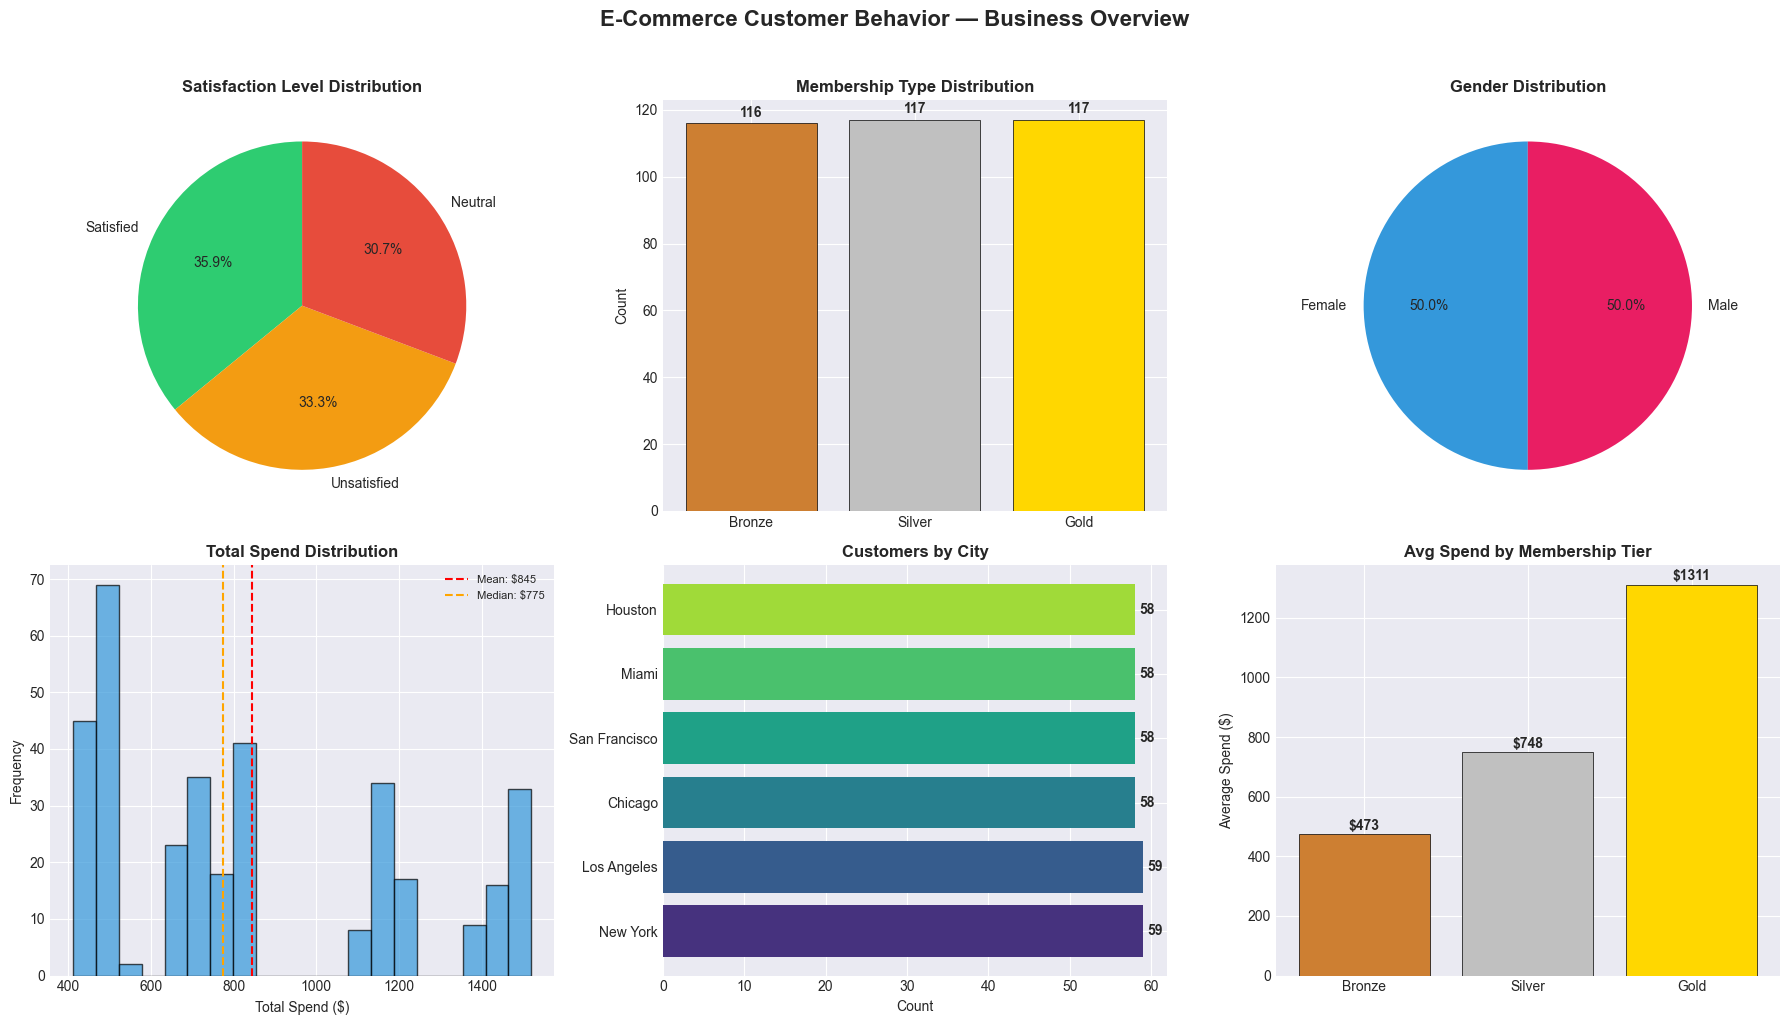

✅ Business overview chart saved as business_overview.png


In [30]:
# Create a comprehensive business overview visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('E-Commerce Customer Behavior — Business Overview', fontsize=16, fontweight='bold', y=1.02)

# 1. Satisfaction Level Distribution
colors_sat = ['#2ecc71', '#f39c12', '#e74c3c']
sat_data = df['Satisfaction Level'].value_counts()
axes[0, 0].pie(sat_data, labels=sat_data.index, colors=colors_sat, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 10})
axes[0, 0].set_title('Satisfaction Level Distribution', fontweight='bold')

# 2. Membership Type Distribution
colors_mem = ['#cd7f32', '#c0c0c0', '#ffd700']
mem_data = df['Membership Type'].value_counts().reindex(['Bronze', 'Silver', 'Gold'])
axes[0, 1].bar(mem_data.index, mem_data.values, color=colors_mem, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Membership Type Distribution', fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(mem_data.values):
    axes[0, 1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# 3. Gender Distribution
colors_gen = ['#3498db', '#e91e63']
gen_data = df['Gender'].value_counts()
axes[0, 2].pie(gen_data, labels=gen_data.index, colors=colors_gen, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 10})
axes[0, 2].set_title('Gender Distribution', fontweight='bold')

# 4. Total Spend Distribution
axes[1, 0].hist(df['Total Spend'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['Total Spend'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Total Spend'].mean():.0f}")
axes[1, 0].axvline(df['Total Spend'].median(), color='orange', linestyle='--', label=f"Median: ${df['Total Spend'].median():.0f}")
axes[1, 0].set_title('Total Spend Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Total Spend ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=8)

# 5. City-wise Customer Count
city_data = df['City'].value_counts()
axes[1, 1].barh(city_data.index, city_data.values, color=sns.color_palette('viridis', len(city_data)))
axes[1, 1].set_title('Customers by City', fontweight='bold')
axes[1, 1].set_xlabel('Count')
for i, v in enumerate(city_data.values):
    axes[1, 1].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# 6. Average Spend by Membership Tier
tier_spend = df.groupby('Membership Type')['Total Spend'].mean().reindex(['Bronze', 'Silver', 'Gold'])
axes[1, 2].bar(tier_spend.index, tier_spend.values, color=colors_mem, edgecolor='black', linewidth=0.5)
axes[1, 2].set_title('Avg Spend by Membership Tier', fontweight='bold')
axes[1, 2].set_ylabel('Average Spend ($)')
for i, v in enumerate(tier_spend.values):
    axes[1, 2].text(i, v + 15, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('business_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Business overview chart saved as business_overview.png')

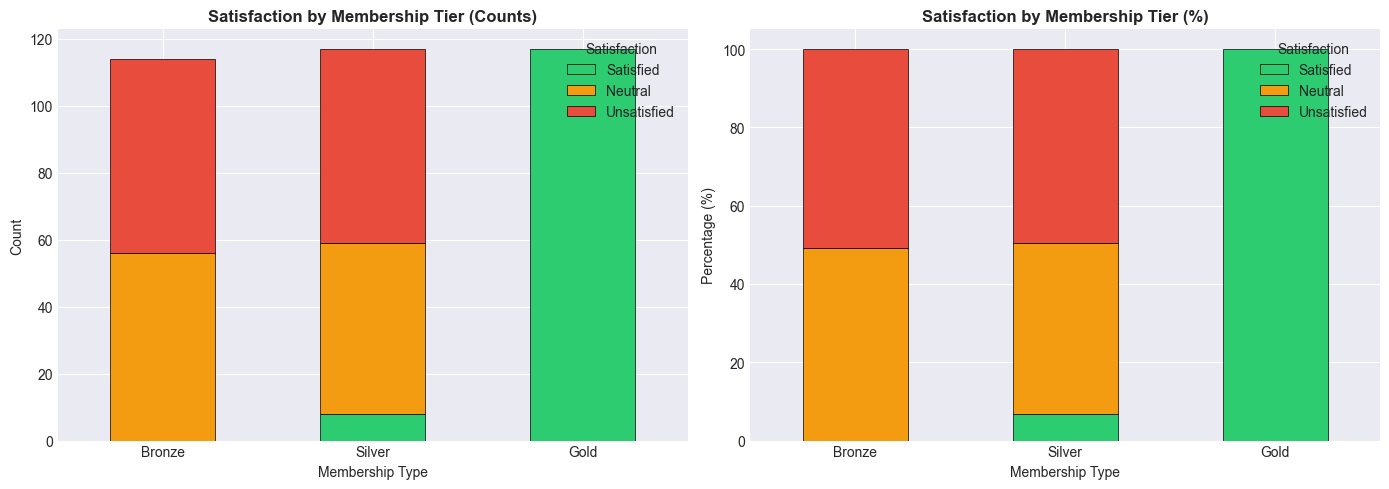

✅ Satisfaction by membership chart saved as satisfaction_by_membership.png


In [31]:
# Satisfaction by Membership Type — Stacked Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
crosstab_plot = pd.crosstab(df['Membership Type'], df['Satisfaction Level'])
crosstab_plot = crosstab_plot.reindex(['Bronze', 'Silver', 'Gold'])
crosstab_plot = crosstab_plot[['Satisfied', 'Neutral', 'Unsatisfied']]
crosstab_plot.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'],
                   edgecolor='black', linewidth=0.5)
axes[0].set_title('Satisfaction by Membership Tier (Counts)', fontweight='bold')
axes[0].set_xlabel('Membership Type')
axes[0].set_ylabel('Count')
axes[0].legend(title='Satisfaction')
axes[0].tick_params(axis='x', rotation=0)

# Percentage stacked bar chart
crosstab_pct_plot = pd.crosstab(df['Membership Type'], df['Satisfaction Level'], normalize='index') * 100
crosstab_pct_plot = crosstab_pct_plot.reindex(['Bronze', 'Silver', 'Gold'])
crosstab_pct_plot = crosstab_pct_plot[['Satisfied', 'Neutral', 'Unsatisfied']]
crosstab_pct_plot.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'],
                       edgecolor='black', linewidth=0.5)
axes[1].set_title('Satisfaction by Membership Tier (%)', fontweight='bold')
axes[1].set_xlabel('Membership Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Satisfaction')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('satisfaction_by_membership.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Satisfaction by membership chart saved as satisfaction_by_membership.png')

---
## 1.6 Success Criteria Definition

| Criteria | Description | Measurement |
|---|---|---|
| **Data Quality** | Clean dataset with no missing values, proper data types | 100% completeness after preparation |
| **Segmentation** | Identify at least 3 meaningful customer segments | Silhouette score > 0.3 |
| **Satisfaction Prediction** | Predict satisfaction with reasonable accuracy | Accuracy > 70% |
| **Actionable Insights** | Minimum 5 actionable business recommendations | Qualitative review |
| **Visualization** | Interactive dashboard with all key metrics | All charts render correctly |

---
## 1.7 Initial Findings & Observations

From our business understanding phase, here are the key initial observations:

In [32]:
# Summary of initial findings
print('='*80)
print('📋 INITIAL FINDINGS SUMMARY — BUSINESS UNDERSTANDING PHASE')
print('='*80)

print('''
1. DATASET SIZE:
   → 350 customers with 11 attributes each
   → Small-to-medium dataset, suitable for detailed analysis

2. DATA QUALITY:
   → 2 missing values found in "Satisfaction Level" column
   → No duplicate rows detected
   → All data types are appropriate

3. CUSTOMER DEMOGRAPHICS:
   → 6 cities: New York, Los Angeles, Chicago, San Francisco, Miami, Houston
   → Age range: 26-43 years (relatively narrow)
   → Gender: roughly balanced distribution

4. MEMBERSHIP DISTRIBUTION:
   → Three tiers: Bronze, Silver, Gold
   → Roughly equal distribution across tiers

5. SPENDING PATTERNS:
   → Wide spending range: $410 - $1520
   → Clear tier differentiation in spending
   → Gold members spend significantly more than others

6. SATISFACTION:
   → Three levels: Satisfied, Neutral, Unsatisfied
   → All three levels have significant representation

7. KEY BUSINESS CONCERN:
   → Unsatisfied customers exist across all segments
   → Understanding churn drivers is critical
   → Membership tier seems to correlate with satisfaction
''')

print('='*80)
print('✅ PHASE 1: BUSINESS UNDERSTANDING — COMPLETE')
print('Next → Phase 2: Data Understanding (Detailed EDA)')
print('='*80)

📋 INITIAL FINDINGS SUMMARY — BUSINESS UNDERSTANDING PHASE

1. DATASET SIZE:
   → 350 customers with 11 attributes each
   → Small-to-medium dataset, suitable for detailed analysis

2. DATA QUALITY:
   → 2 missing values found in "Satisfaction Level" column
   → No duplicate rows detected
   → All data types are appropriate

3. CUSTOMER DEMOGRAPHICS:
   → 6 cities: New York, Los Angeles, Chicago, San Francisco, Miami, Houston
   → Age range: 26-43 years (relatively narrow)
   → Gender: roughly balanced distribution

4. MEMBERSHIP DISTRIBUTION:
   → Three tiers: Bronze, Silver, Gold
   → Roughly equal distribution across tiers

5. SPENDING PATTERNS:
   → Wide spending range: $410 - $1520
   → Clear tier differentiation in spending
   → Gold members spend significantly more than others

6. SATISFACTION:
   → Three levels: Satisfied, Neutral, Unsatisfied
   → All three levels have significant representation

7. KEY BUSINESS CONCERN:
   → Unsatisfied customers exist across all segments
   →

---
## 📝 Phase 1 Conclusion

In this phase, we have:

- ✅ Loaded the dataset and performed initial inspection using `head()`, `tail()`, `shape`, `columns`, `dtypes`, `info()`, `describe()`, `sample()`, `nunique()`, `value_counts()`, `isnull()`, `duplicated()`, and `memory_usage()`
- ✅ Defined the **business background** and **stakeholders**
- ✅ Identified **5 key business objectives** with priority levels
- ✅ Formulated **12 business questions** (descriptive, diagnostic, predictive, prescriptive)
- ✅ Created a comprehensive **data dictionary** with business meanings
- ✅ Computed initial **KPIs** and **business snapshot**
- ✅ Performed initial **cross-tabulations** (Membership × Satisfaction)
- ✅ Created initial **visualizations** for business context
- ✅ Defined **success criteria** for the project
- ✅ Documented **initial findings and observations**

### 🔜 Next Steps → Phase 2: Data Understanding
In the next notebook, we will perform detailed **Exploratory Data Analysis (EDA)** including:
- Distribution analysis for all variables
- Correlation analysis
- Outlier detection
- Deeper cross-tabulations and group-by analyses
- Advanced visualizations